Part A - Theoretical Foundation

Que.1 What is Statistical Distribution?

Ans:- A statistical distribution means values are spread or distributed across different possible values.

Que.2 What is a Q-Q Plot and Why is it Used?

Ans:- A Q-Q Plot (Quantile-Quantile Plot) is used to check whether your data follows a specific distribution.

Que.3 Difference Between Discrete and Continuous Distributions

Ans:- Discrete means countable numbers for eg:- age, transitions etc. Continuous means real number (in float) for eg:- tempreature, bill amount

Que.4 What is Bernoulli Distribution?

Ans:- Bernoulli Distribution models experiments with only two outcomes.

Que.5 What is Binomial Distribution?

Ans:- Binomial Distribution describes number of successes in multiple trials.

Que.6 Log-Normal Distribution

Ans:- A variable follows log-normal distribution if its logarithm is normally distributed.

Que.7 Power Law Distribution

Ans:- Power Law Distribution describes situations where few values are extremely large and many are small.

Que.8 What is Box-Cox Transform?

Ans:- Box-Cox transformation is used to make skewed data more normal.

Que.9 Poisson Distribution with an example

Ans:- Poisson Distribution models take number of probability events in happens in fixed time interval.

Que.10 What is Z-Score Probability?

Ans:- Z-score tells how far a value is from the mean in standard deviations.

Part B - Data Analysis & Testing

In [2]:
import pandas as pd
df = pd.read_excel("spread_locator_dataset.xlsx")

df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


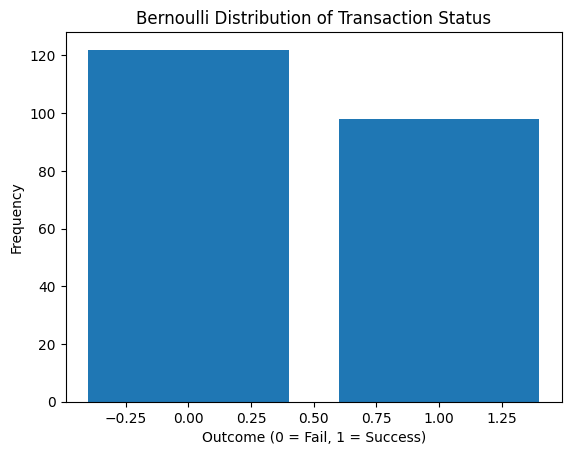

In [21]:
#Task 1 - Bernoulli Distribution
import matplotlib.pyplot as plt

# Count success and fail
counts = df["success"].value_counts()

plt.bar(counts.index, counts.values)

plt.title("Bernoulli Distribution of Transaction Status")
plt.xlabel("Outcome (0 = Fail, 1 = Success)")
plt.ylabel("Frequency")

plt.show()

Average number of trials (n): 2
Probability of Success: 0.44545454545454544


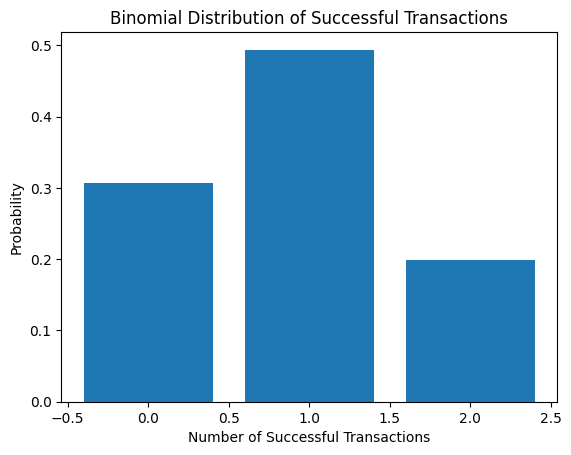

In [24]:
#Task 2 - Binomial Distribution.
import numpy as np
from scipy import stats

n = int(df["transaction_count"].mean())
print("Average number of trials (n):", n)

p = df["success"].mean()
print("Probability of Success:", p)

x = np.arange(0, n+1)
y = stats.binom.pmf(x, n, p)

plt.bar(x, y)

plt.title("Binomial Distribution of Successful Transactions")
plt.xlabel("Number of Successful Transactions")
plt.ylabel("Probability")

plt.show()



Average transactions per day: 2.8545454545454545


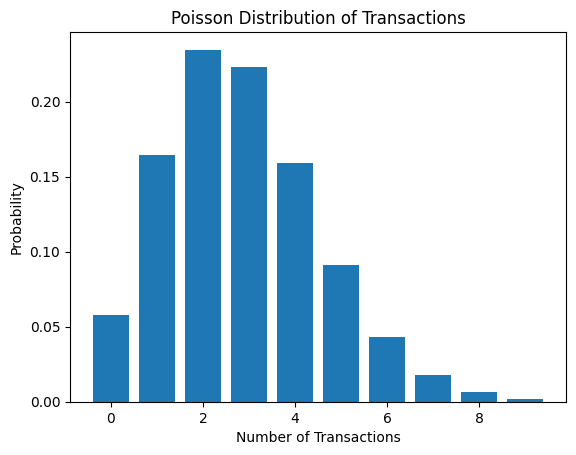

In [25]:
#Task 3 - Poisson Distribution

lambda_val = df["transaction_count"].mean()
print("Average transactions per day:", lambda_val)

x = np.arange(0,10)
y = stats.poisson.pmf(x, lambda_val)

plt.bar(x,y)

plt.title("Poisson Distribution of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Probability")

plt.show()

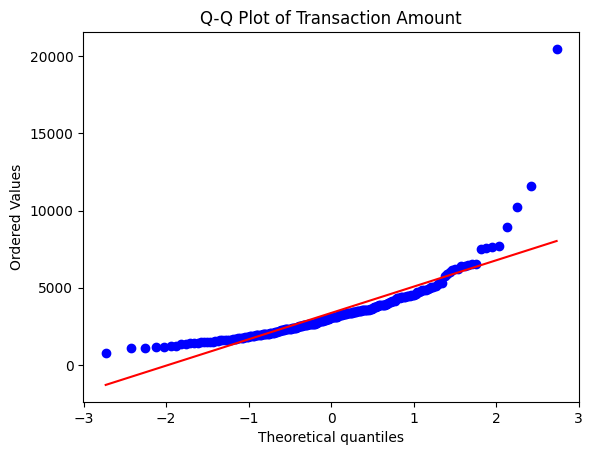

In [28]:
#Task 4 - Q-Q Plot

stats.probplot(df["transaction_amount"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Transaction Amount")
plt.show()

Box-Cox Lambda: -0.18083390743966327


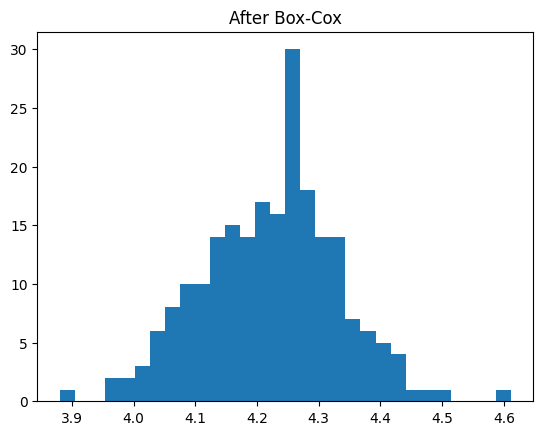

In [32]:
#Task 5 - Log-Normal Distribution

transformed, lam_box = stats.boxcox(df["transaction_amount"])
print("Box-Cox Lambda:", lam_box)

plt.hist(transformed, bins=30)
plt.title("After Box-Cox")
plt.show()

In [33]:
#Task 6 - Z-Score
m = df["transaction_amount"].mean()
s = df["transaction_amount"].std()

z = (5000 - m) / s
prob = 1 - stats.norm.cdf(5000, m, s)

print("Z-score for 5000:", z)
print("Probability > 5000:", prob)

Z-score for 5000: 0.8232880785671723
Probability > 5000: 0.20517209567554384


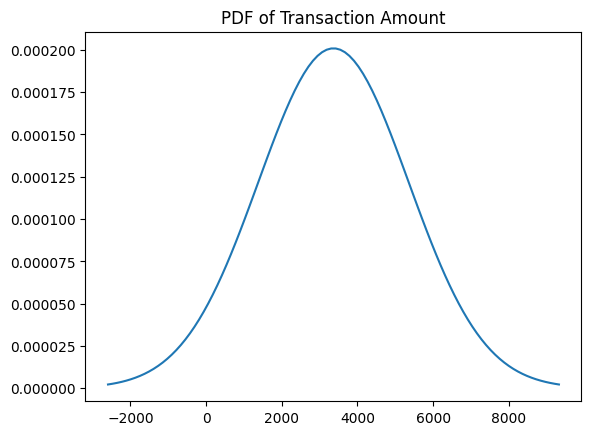

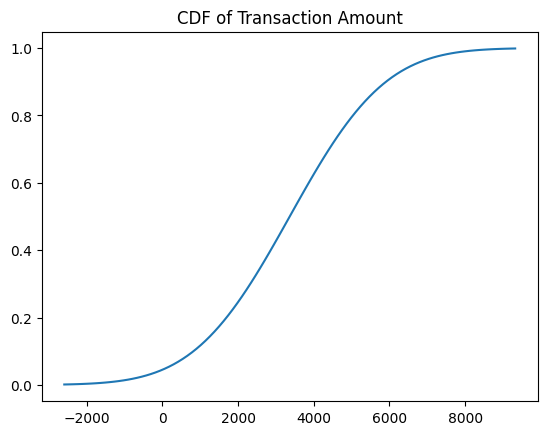

In [44]:
# Task 7 - PDF & CDF

pdf = stats.norm.pdf(df["transaction_amount"], m, s)
cdf = stats.norm.cdf(df["transaction_amount"], m, s)

x = np.linspace(m-3*s, m+3*s, 100)
y = stats.norm.pdf(x, m, s)

plt.plot(x,y)
plt.title("PDF of Transaction Amount")
plt.show()

z = stats.norm.cdf(x, m, s)

plt.plot(x,z)
plt.title("CDF of Transaction Amount")
plt.show()